In [86]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [87]:
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 3)
    & (tourney_df['Illinois'] > 3)
    & (tourney_df['Duke'] > 2)
    & (tourney_df['Michigan'] > 2)
    & (tourney_df['Connecticut'] > 2)
    & (tourney_df['Tennessee'] > 2)
    ]
tourney_df.Probability = tourney_df.Probability / tourney_df.Probability.sum()

In [88]:
win_df = tourney_df[['Winner', 'Probability']].groupby(['Winner']).sum()
win_df.sort_values(by='Probability', ascending=False, inplace=True)

win_df_nice = win_df.copy()
win_df_nice = win_df_nice.loc[win_df_nice['Probability'] > 0.00000005]
other = 1.0 - win_df_nice['Probability'].sum()
if other > 0.0001:
    win_df_nice.loc['Other'] = [other]

second_df = tourney_df[['Second', 'Probability']].groupby(['Second']).sum()
second_df.sort_values(by='Probability', ascending=False, inplace=True)

second_df_nice = second_df.copy()
second_df_nice = second_df_nice.loc[second_df_nice['Probability'] > 0.03]
other = 1.0 - second_df_nice['Probability'].sum()
if other > 0.0001:
    second_df_nice.loc['Other'] = [other]

third_df = tourney_df[['Third', 'Probability']].groupby(['Third']).sum()
third_df.sort_values(by='Probability', ascending=False, inplace=True)

third_df_nice = third_df.copy()
third_df_nice = third_df_nice.loc[third_df_nice['Probability'] > 0.00000005]
other = 1.0 - third_df_nice['Probability'].sum()
if other > 0.0001:
    third_df_nice.loc['Other'] = [other]


In [89]:
all_labels = set(win_df_nice.index) | set(second_df_nice.index) | set(third_df_nice.index)

In [90]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [91]:
from math import sin, cos, sqrt, gcd, pi

seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

Dan Wros
Danny Ryan
George Wright
Justin Calvillo
Keith Schneider
Keith Schneider, Mark Hurst
Koy Kubasta
Mark Hurst
Nathan Sanches
Other
Patrick Commers
Serigne Diaw
Tyler Krause
none


{'Serigne Diaw': [0.5690355937288492, 0.9633731610262555, 0.6746980264314426],
 'Dan Wros': [0.5132268258921863, 0.9143579088567831, 0.7795220464375778],
 'none': [0.5014820463410552, 0.8299577144418173, 0.8756670204036747],
 'Keith Schneider': [0.5361274527058262,
  0.7268890713856979,
  0.9440902570950231],
 'Patrick Commers': [0.6103010973579309,
  0.6255659884996431,
  0.9712396953289734],
 'Mark Hurst': [0.7093119802939664, 0.5460567449952987, 0.9517380558972823],
 'Nathan Sanches': [0.8135497818596592,
  0.5041091216655798,
  0.8894478776613084],
 'Danny Ryan': [0.9023689270621824, 0.5080313597647761, 0.796706494359589],
 'Keith Schneider, Mark Hurst': [0.9581776948988453,
  0.5570466119342484,
  0.6918824743534537],
 'Koy Kubasta': [0.9699224744499764, 0.6414468063492142, 0.5957375003873568],
 'Tyler Krause': [0.9352770680852054, 0.7445154494053335, 0.5273142636960083],
 'Justin Calvillo': [0.8611034234331006,
  0.8458385322913885,
  0.5001648254620582],
 'Other': [0.76209254049

In [92]:
dfs = [win_df_nice, second_df_nice, third_df_nice]
disp_titles = ['1st Place', '2nd Place', '3rd Place']

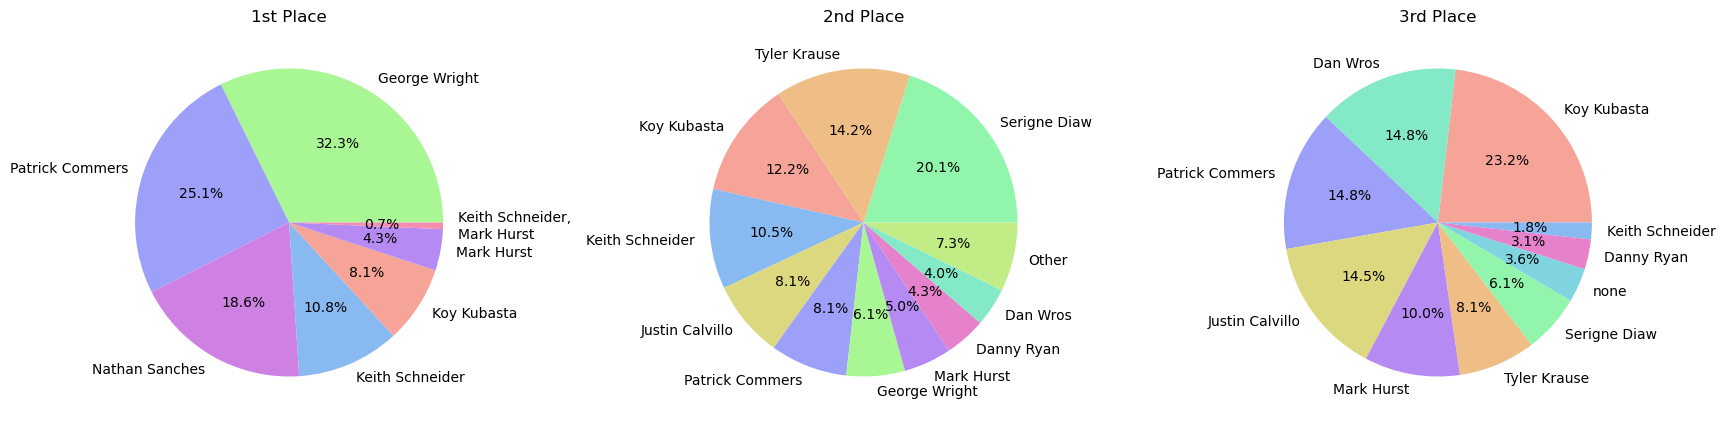

In [93]:
fig, axs = plt.subplots(1, 3, figsize = [21, 5])

for ax, title, df in zip(axs.flatten(), disp_titles, dfs):
    labels=df.index
    colors = [color_dict[label] for label in labels]
    labels = [_.replace(', ', ',\n') for _ in labels]
    ax.pie(df['Probability'], 
           labels=labels,
           autopct='%1.1f%%',
           normalize=True,
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')

plt.savefig('plots/win_place_show_saturday.png', dpi=300, bbox_inches='tight')

In [94]:
pot = 425.0
prizes = {
    1: 0.6 * pot,
    2: 0.3 * pot,
    3: .01 * pot
}

ev_dict = {}

for winner in win_df.index:
    winners = winner.split(', ')
    prob = win_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[1]
    elif nwinners == 2:
        total_prize = prizes[1] + prizes[2]
    else:
        total_prize = prizes[1] + prizes[2] + prizes[3]
    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in second_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = second_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[2]
    else:
        total_prize = prizes[2] + prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in third_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = third_df.loc[winner, 'Probability']
    nwinners = len(winners)
    total_prize = prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 
# ev_dict

ev_df = pd.DataFrame.from_dict(data=ev_dict, orient='index', columns=['EV (USD)'])
ev_df.sort_values(by='EV (USD)', ascending=False, inplace=True)
ev_df['EV (GBP)'] = ev_df['EV (USD)']  * 0.75
ev_df
    

,EV (USD),EV (GBP)
George Wright,91.814174,68.860631
Patrick Commers,75.096300,56.322225
Nathan Sanches,51.232926,38.424694
Keith Schneider,43.073258,32.304943
Koy Kubasta,37.218437,27.913827
Serigne Diaw,25.945159,19.458870
Tyler Krause,20.020791,15.015593
Mark Hurst,19.941643,14.956233
Justin Calvillo,10.965603,8.224202
Dan Wros,5.783367,4.337525


In [95]:
from IPython.display import display

display(ev_df.style.format({
    'EV (USD)': '${:,.2f}',
    'EV (GBP)': '£{:,.2f}' # Example for a different currency without decimals
}))



,EV (USD),EV (GBP)
George Wright,$91.81,£68.86
Patrick Commers,$75.10,£56.32
Nathan Sanches,$51.23,£38.42
Keith Schneider,$43.07,£32.30
Koy Kubasta,$37.22,£27.91
Serigne Diaw,$25.95,£19.46
Tyler Krause,$20.02,£15.02
Mark Hurst,$19.94,£14.96
Justin Calvillo,$10.97,£8.22
Dan Wros,$5.78,£4.34


In [96]:
print(ev_df)

                  EV (USD)   EV (GBP)
George Wright    91.814174  68.860631
Patrick Commers  75.096300  56.322225
Nathan Sanches   51.232926  38.424694
Keith Schneider  43.073258  32.304943
Koy Kubasta      37.218437  27.913827
Serigne Diaw     25.945159  19.458870
Tyler Krause     20.020791  15.015593
Mark Hurst       19.941643  14.956233
Justin Calvillo  10.965603   8.224202
Dan Wros          5.783367   4.337525
Danny Ryan        5.658343   4.243757


In [97]:
pd.set_option('display.max_colwidth', 70)
print(win_df)

                             Probability
Winner                                  
George Wright                   0.323040
Patrick Commers                 0.251486
Nathan Sanches                  0.185942
Keith Schneider                 0.108156
Koy Kubasta                     0.081090
Mark Hurst                      0.043331
Keith Schneider, Mark Hurst     0.006955


In [98]:
pd.set_option('display.max_colwidth', 70)
print(second_df)

                             Probability
Second                                  
Serigne Diaw                    0.201447
Tyler Krause                    0.141614
Koy Kubasta                     0.122008
Keith Schneider                 0.104771
Justin Calvillo                 0.081170
Patrick Commers                 0.081090
George Wright                   0.061323
Mark Hurst                      0.050234
Danny Ryan                      0.043331
Dan Wros                        0.040422
Nathan Sanches                  0.029944
George Wright, Tyler Krause     0.024598
Keith Schneider, Mark Hurst     0.011092
none                            0.006955


In [99]:
pd.set_option('display.max_colwidth', 70)
print(third_df)

                 Probability
Third                       
Koy Kubasta         0.231619
Dan Wros            0.148139
Patrick Commers     0.147830
Justin Calvillo     0.145029
Mark Hurst          0.100340
Tyler Krause        0.081090
Serigne Diaw        0.061323
none                0.035690
Danny Ryan          0.031430
Keith Schneider     0.017509
